In [68]:
%%capture --no-stderr
%pip install --quiet -U langchain_openai langchain_core langgraph langchain_community langchain_anthropic langchain_experimental faiss-cpu tiktoken pypdf langchain openai langchain_anthropic langchain_experimental

     ---------------------------------------- 13.7/13.7 MB 4.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [131]:
# Importación de librerias
# LangGraph
from langgraph.graph import START, END, StateGraph
from langgraph.types import Command
from langgraph.prebuilt import create_react_agent

# LangChain
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.tools.retriever import create_retriever_tool
from langchain.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
# Utilidades
from typing import TypedDict, Optional, Dict, List, Literal, Annotated
from dotenv import load_dotenv, find_dotenv
import tiktoken
from IPython.display import Image, display


In [132]:
# Carga de variables de entorno
dotenv_path = find_dotenv()
load_dotenv(dotenv_path)


True

In [133]:
def count_tokens_in_docs(docs, model_name="gpt-4o"):
    """
    Calcula la cantidad total de tokens para una lista de documentos
    usando la librería tiktoken.

    :param docs: Lista de documentos (por ejemplo, la salida de un loader PDF).
    :param model_name: Nombre del modelo para el que queremos simular el conteo.
    :return: Número total de tokens en el contenido de los documentos.
    """
    # Obtenemos la codificación que usa el modelo seleccionado
    encoding = tiktoken.encoding_for_model(model_name)

    total_tokens = 0
    for doc in docs:
        # doc.page_content es el texto de cada página/documento
        text = doc.page_content
        total_tokens += len(encoding.encode(text))

    return total_tokens

In [134]:
# 2. CARGA DEL PDF
# ----------------------------------------------------------------------------
file_path = "carga.pdf"
loader = PyPDFLoader(file_path)
docs = loader.load()

In [135]:
# Cantidad de documentos extraídos (páginas, secciones, etc. según PyPDFLoader)
print("Número de docs cargados:", len(docs))

# Opcional: vista previa de los primeros 100 caracteres de la primera página
print("Preview contenido:", docs[0].page_content[0:100])
print("Metadata:", docs[0].metadata)

Número de docs cargados: 4
Preview contenido: Carga de datos 
 
Este proceso permite agregar en la liquidación de sueldos del trabajador, valores 
Metadata: {'producer': 'Microsoft® Word para Microsoft 365', 'creator': 'Microsoft® Word para Microsoft 365', 'creationdate': '2022-08-29T22:01:31-04:00', 'author': 'Juan Carlos Rojas Banda', 'moddate': '2022-08-29T22:01:31-04:00', 'source': 'carga.pdf', 'total_pages': 4, 'page': 0, 'page_label': '1'}


In [136]:
# 3. CONTAR TOKENS ANTES DE HACER NADA
# ----------------------------------------------------------------------------
tokens_en_documento = count_tokens_in_docs(docs, model_name="gpt-4o")
print("Tokens en el documento completo:", tokens_en_documento)

Tokens en el documento completo: 854


In [137]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=20)
splits = text_splitter.split_documents(docs)


In [138]:
# Crea los embeddings
embeddings = OpenAIEmbeddings()
vectorstore = FAISS.from_documents(splits, embeddings)

# Crea el retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

In [139]:
# Modelo utilizado
llm = ChatOpenAI(model="gpt-4o")

In [140]:
# Creación del estado
class GlobalState(TypedDict): # Estado Globa
    graph: str
    messages: list[dict] # Es una lista de diccionarios
    next: str
    
class SearchState(TypedDict):
    search: List[dict]

In [141]:
# Miembros del equipo
members = ["researcher", "retriever", "amparo"]
options = members + ["FINISH"]

In [142]:
# Router con opciones para el llm
class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH."""

    next: Literal["researcher", "retriever","amparo",  "FINISH"]

In [143]:
system_prompt = (
    "Tu nombre es Amparo, un asistente virtual que apoya las gestiones en el área de Recursos Humanos "
    "de la empresa Constructora del Mar II. Tu función principal es gestionar las solicitudes del usuario "
    f"derivándolas a los siguientes agentes especializados: {members}.\n\n"
    
    "El agente especializado 'researcher' se encarga de realizar búsquedas de información en la web.\n"
    "El agente especializado 'retriever' se encarga de recuperar información desde un documento llamado 'Carga de Datos'. "
    "Este documento contiene instrucciones sobre cómo cargar información en el módulo UnyRem del ERP Unysoft.\n\n"
    
    "Tu tarea es analizar la pregunta del usuario y decidir cuál agente debe actuar en función de la solicitud.\n"
    "Si la solicitud es general o informal, selecciona el agente más apropiado para responder o investigar.\n"
    "Responde 'FINISH' el miembro a quien designaste la tarea ya la finalizó.\n\n"
    
    "Devuelve **únicamente** el nombre del trabajador a activar (por ejemplo: retriever), o 'FINISH' si todo ha concluido."
)


print(system_prompt)


Tu nombre es Amparo, un asistente virtual que apoya las gestiones en el área de Recursos Humanos de la empresa Constructora del Mar II. Tu función principal es gestionar las solicitudes del usuario derivándolas a los siguientes agentes especializados: ['researcher', 'retriever', 'amparo'].

El agente especializado 'researcher' se encarga de realizar búsquedas de información en la web.
El agente especializado 'retriever' se encarga de recuperar información desde un documento llamado 'Carga de Datos'. Este documento contiene instrucciones sobre cómo cargar información en el módulo UnyRem del ERP Unysoft.

Tu tarea es analizar la pregunta del usuario y decidir cuál agente debe actuar en función de la solicitud.
Si la solicitud es general o informal, selecciona el agente más apropiado para responder o investigar.
Responde 'FINISH' el miembro a quien designaste la tarea ya la finalizó.

Devuelve **únicamente** el nombre del trabajador a activar (por ejemplo: retriever), o 'FINISH' si todo h

In [153]:
# Definir un nodo info o agent principal
system_prompt_amparo = "Eres Amparo un asistente virtual creado para apoyar al depto de rrhh de la empresa consstructora del mar. Tu trabajo consiste en responder a las solicitudes de los usuarios"
info_agent = create_react_agent(
    llm,
    tools=[],
    prompt=ChatPromptTemplate.from_messages([
        ("system", system_prompt_amparo),
        ("human", "{messages}")
    ])
)

def amparo(state: GlobalState) -> Command[Literal["supervisor"]]:
    result = info_agent.invoke(state)
    print("RESPUESTA DE AMPARO: \n")
    print(result["messages"])
    return Command(
        goto="supervisor",
        update={"messages": result["messages"]}
    )



In [227]:
from langchain_core.messages import AIMessage
def supervisor_node(state: GlobalState) -> Command[Literal["researcher", "retriever","amparo", "__end__"]]:
    print("Este es el mensaje que recibe el supervisor: \n")
    print(state["messages"])
    ultimo_ai = next(
        (msg for msg in reversed(state["messages"]) if isinstance(msg, AIMessage)),
        None  # Valor por defecto si no se encuentra ninguno
)
    print("ULTIMO AI: ", ultimo_ai)
    
    if ultimo_ai:
        ultimo_ai= ultimo_ai.content
        ultimo_ai= list(ultimo_ai)
        messages = [{"role":"system", "content":system_prompt},] + ultimo_ai
    else:
        messages = [{"role":"system", "content":system_prompt},] + state["messages"]
    response = llm.with_structured_output(Router).invoke(messages)
    goto = response["next"]
    print("DIRIGIENDO FLUJO A: ", goto)
    if goto == "FINISH":
        goto = END
    
    return Command(goto=goto, update = {"next":goto})

In [228]:
# Tool de search node 
tavily_tool = TavilySearchResults(max_results=1)
research_agent = create_react_agent(
    llm, tools=[tavily_tool], prompt="Eres un agente especializado en busqueda web."
)

In [229]:
def search_node(state: GlobalState) -> Command[Literal["supervisor"]]:
    result = research_agent.invoke(state)
    # print("DEBUG result: ", result)  # <-- esto

    return Command(goto="supervisor", 
                   update = {
                       "__state__": {"search":result["messages"]},"messages":result["messages"]})

In [230]:
# Crea una herramienta a partir del retriever
retriever_tool = create_retriever_tool(
    retriever,
    name="reglamento_retriever",
    description="Busca información manual de Unyrem de Unysoft."
)

In [231]:
# Crea el agente con la herramienta
retriever_agent = create_react_agent(
    llm,
    tools=[retriever_tool],
    prompt="Eres un agente experto en responder preguntas sobre el manual de carga de datos al módulo UnyRem del sistema Unysoft,"
)

In [232]:
def retriever_node(state: GlobalState) -> Command[Literal["supervisor"]]:
    result = retriever_agent.invoke(state)
    return Command(
        goto="supervisor",
        update={
            "messages": result["messages"]
        }
    )


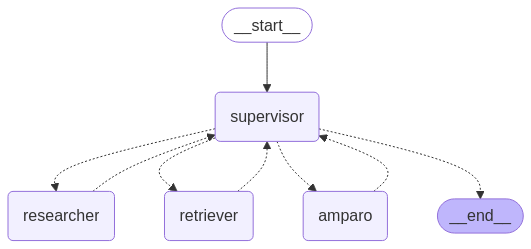

In [233]:
builder = StateGraph(GlobalState)
builder.add_edge(START, "supervisor")
builder.add_node("amparo", amparo)
builder.add_node("supervisor", supervisor_node)
builder.add_node("researcher",search_node)
builder.add_node("retriever",retriever_node)

graph =  builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [234]:
sal = graph.invoke({"messages": ["¿Como te llamas y cuales son tus funciones?"]})
for m in sal["messages"]:
    m.pretty_print()


Este es el mensaje que recibe el supervisor: 

['¿Como te llamas y cuales son tus funciones?']
ULTIMO AI:  None
DIRIGIENDO FLUJO A:  amparo
RESPUESTA DE AMPARO: 

[HumanMessage(content='¿Como te llamas y cuales son tus funciones?', additional_kwargs={}, response_metadata={}, id='c5eda528-8829-439d-b284-c08b5ff12447'), AIMessage(content='Soy Amparo, tu asistente virtual de Recursos Humanos para la empresa Constructora del Mar. Estoy aquí para ayudarte con cualquier consulta o solicitud relacionada con procesos de Recursos Humanos, como información sobre beneficios, políticas de la empresa, procedimientos de contratación, o cualquier otra pregunta que puedas tener dentro del ámbito de RRHH. ¡Estoy para apoyarte en lo que necesites!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 75, 'prompt_tokens': 92, 'total_tokens': 167, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_pred

KeyboardInterrupt: 